## Set up

In [33]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [34]:
print(os.getcwd())
if os.getcwd().endswith("notebooks"):
    os.chdir("..")
print(os.getcwd())

d:\code\Python\DSEB_ex\MLops
d:\code\Python\DSEB_ex\MLops


In [35]:
base_path = Path(os.getcwd())
data_path = base_path / "data" / "raw"
data_path1 = data_path / "origination_data-2.csv"
data_path2 = data_path / "monthly_performance-2.csv"

df1 = pd.read_csv(data_path1)
df2 = pd.read_csv(data_path2)

In [36]:
# ===== HELPER FUNCTIONS FOR DATA ANALYSIS =====
from scipy.stats import gaussian_kde

def get_summary_stats(df, cols):
    """Generate summary statistics for list of columns"""
    summary = []
    for col in cols:
        summary.append({
            'Column': col,
            'Type': df[col].dtype,
            'Count': df[col].count(),
            'Missing': df[col].isnull().sum(),
            'Missing %': f"{df[col].isnull().sum()/len(df)*100:.2f}%"
        })
    return pd.DataFrame(summary)

def get_categorical_summary(df, cols):
    """Summary for categorical columns"""
    summary = []
    for col in cols:
        summary.append({
            'Column': col,
            'Type': df[col].dtype,
            'Unique': df[col].nunique(),
            'Count': df[col].count(),
            'Missing': df[col].isnull().sum(),
            'Missing %': f"{df[col].isnull().sum()/len(df)*100:.2f}%",
            'Most Frequent': df[col].value_counts().index[0] if len(df[col].value_counts()) > 0 else 'N/A',
            'Freq Count': df[col].value_counts().values[0] if len(df[col].value_counts()) > 0 else 0
        })
    return pd.DataFrame(summary)

def get_numerical_summary(df, cols):
    """Summary for numerical columns"""
    summary = []
    for col in cols:
        data = df[col].dropna()
        summary.append({
            'Column': col,
            'Type': df[col].dtype,
            'Count': df[col].count(),
            'Missing': df[col].isnull().sum(),
            'Missing %': f"{df[col].isnull().sum()/len(df)*100:.2f}%",
            'Mean': f"{data.mean():.4f}",
            'Std': f"{data.std():.4f}",
            'Min': f"{data.min():.4f}",
            'Max': f"{data.max():.4f}"
        })
    return pd.DataFrame(summary)

def print_categorical_details(df, cols):
    """Print detailed statistics for categorical columns"""
    print("\n" + "="*100)
    print("DETAILED CATEGORICAL STATISTICS")
    print("="*100)
    
    for col in cols:
        print(f"\n{'-'*100}")
        print(f"Feature: {col}")
        print(f"{'-'*100}")
        
        # Số lượng unique values
        n_unique = df[col].nunique()
        print(f"Unique values: {n_unique}")
        
        # Danh sách unique values
        unique_vals = df[col].unique().tolist()
        if len(unique_vals) <= 20:
            print(f"Values: {unique_vals}")
        else:
            print(f"Values: {unique_vals[:20]} ... (showing first 20 of {len(unique_vals)})")
        
        # Số lượng missing values
        missing = df[col].isnull().sum()
        print(f"Missing values: {missing} ({missing/len(df)*100:.2f}%)")
        
        # Frequency distribution
        print(f"\nFrequency Distribution:")
        freq = df[col].value_counts()
        freq_pct = df[col].value_counts(normalize=True) * 100
        freq_table = pd.DataFrame({
            'Count': freq,
            'Percentage': freq_pct,
            'Cumulative %': freq_pct.cumsum()
        })
        print(freq_table)

def print_numerical_details(df, cols):
    """Print detailed statistics for numerical columns"""
    print("\n" + "="*100)
    print("DETAILED NUMERICAL STATISTICS")
    print("="*100)
    
    for col in cols:
        print(f"\n{'-'*100}")
        print(f"Feature: {col}")
        print(f"{'-'*100}")
        
        data = df[col].dropna()
        
        # Basic statistics
        print(f"Count: {len(data)}")
        print(f"Missing values: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.2f}%)")
        print(f"\nDescriptive Statistics:")
        print(f"  Mean: {data.mean():.4f}")
        print(f"  Median: {data.median():.4f}")
        mode_val = data.mode().values[0] if len(data.mode()) > 0 else None
        mode_str = f"{mode_val:.4f}" if mode_val is not None else "No mode"
        print(f"  Mode: {mode_str}")
        print(f"  Std Dev: {data.std():.4f}")
        print(f"  Min: {data.min():.4f}")
        print(f"  25%: {data.quantile(0.25):.4f}")
        print(f"  50%: {data.quantile(0.50):.4f}")
        print(f"  75%: {data.quantile(0.75):.4f}")
        print(f"  Max: {data.max():.4f}")
        print(f"  Range: {data.max() - data.min():.4f}")
        print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.4f}")
        
        # Distribution shape
        print(f"\nDistribution Shape:")
        skewness = stats.skew(data)
        kurtosis = stats.kurtosis(data)
        print(f"  Skewness: {skewness:.4f}", end="")
        if abs(skewness) < 0.5:
            print(" (Fairly Symmetric)")
        elif skewness > 0.5:
            print(" (Right-skewed)")
        else:
            print(" (Left-skewed)")
        
        print(f"  Kurtosis: {kurtosis:.4f}", end="")
        if abs(kurtosis) < 3:
            print(" (Platykurtic - Lighter tails)")
        elif abs(kurtosis) > 3:
            print(" (Leptokurtic - Heavier tails)")
        else:
            print(" (Mesokurtic - Normal-like)")
        
        # Normality test (Shapiro-Wilk)
        if len(data) <= 5000:
            stat, p_value = stats.shapiro(data)
            print(f"  Normality Test (Shapiro-Wilk): p-value = {p_value:.6f}", end="")
            if p_value > 0.05:
                print(" (Normal distribution)")
            else:
                print(" (Non-normal distribution)")
        else:
            print(f"  Normality Test (Shapiro-Wilk): Skipped (n={len(data)} > 5000)")

def plot_categorical_distributions(df, cols, max_cols_per_row=2, max_unique=50):
    """Plot bar charts for categorical distributions
    
    Args:
        df: DataFrame
        cols: List of column names
        max_cols_per_row: Number of subplots per row
        max_unique: Skip plotting if unique values > this threshold (too slow)
    """
    if not cols:
        print("No categorical columns to plot")
        return
    
    # Filter columns to plot (skip high-cardinality columns)
    plottable_cols = []
    skipped_cols = []
    
    for col in cols:
        n_unique = df[col].nunique()
        if n_unique > max_unique:
            skipped_cols.append((col, n_unique))
        else:
            plottable_cols.append(col)
    
    # Show warnings
    if skipped_cols:
        print("⚠️  Skipped plotting (too many unique values):")
        for col, n_unique in skipped_cols:
            print(f"   - {col}: {n_unique} unique values")
        print()
    
    if not plottable_cols:
        print("No columns to plot (all have too many unique values)")
        return
    
    n_cat = len(plottable_cols)
    n_rows = (n_cat + max_cols_per_row - 1) // max_cols_per_row
    fig, axes = plt.subplots(n_rows, max_cols_per_row, figsize=(5*max_cols_per_row, 4*n_rows))
    
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for idx, col in enumerate(plottable_cols):
        ax = axes[idx]
        df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'Frequency Distribution: {col}', fontsize=12, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.grid(axis='y', alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(plottable_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def plot_numerical_distributions(df, cols, max_cols_per_row=2):
    """Plot histograms with KDE curves for numerical distributions"""
    if not cols:
        print("No numerical columns to plot")
        return
    
    n_num = len(cols)
    n_rows = (n_num + max_cols_per_row - 1) // max_cols_per_row
    fig, axes = plt.subplots(n_rows, max_cols_per_row, figsize=(5*max_cols_per_row, 4*n_rows))
    
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for idx, col in enumerate(cols):
        ax = axes[idx]
        data = df[col].dropna()
        ax.hist(data, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
        
        kde = gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 100)
        ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
        
        ax.set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def plot_correlation_heatmap(df, cols, figsize=(12, 10)):
    """Plot correlation heatmap for numerical columns"""
    if not cols:
        print("No columns to plot")
        return
    
    # Calculate correlation matrix
    corr_matrix = df[cols].corr()
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=ax, vmin=-1, vmax=1)
    ax.set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

print("✓ All helper functions loaded.")

✓ All helper functions loaded.


## Data 1: origination_data-2.csv

In [37]:
df1.head()

,customer_id,application_date,age,gender,employment_status,annual_income,monthly_income,loan_amount,interest_rate,loan_term,emi,dti,credit_score_origination,revolving_utilization_origination,credit_inquiries_12m,deterioration_pattern,default_12m,vintage_year,vintage_month
0,CUST100000,2022-04-08,42,Male,Self-Employed,83834.0,6986.17,50000.0,12.33,36,1668.61,0.35,720,0.433,0,stable,0,2022,2022-04
1,CUST100001,2024-04-28,35,Female,Employed,56472.0,4706.00,50000.0,10.98,48,1291.79,0.41,658,0.250,1,gradual_decline,0,2024,2024-04
2,CUST100002,2023-12-19,44,Male,Employed,165696.0,13808.00,50000.0,9.71,84,822.59,0.44,801,0.339,2,stable,0,2023,2023-12
3,CUST100003,2023-04-27,41,Female,Employed,79943.0,6661.92,50000.0,14.42,36,1719.10,0.38,743,0.617,0,gradual_decline,0,2023,2023-04
4,CUST100004,2023-04-20,28,Female,Employed,160442.0,13370.17,52071.0,10.81,36,1700.06,0.10,662,0.215,1,stable,0,2023,2023-04


In [38]:
df1.describe()

,age,annual_income,monthly_income,loan_amount,interest_rate,loan_term,emi,dti,credit_score_origination,revolving_utilization_origination,credit_inquiries_12m,default_12m,vintage_year
count,135000.000000,1.350000e+05,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000,135000.000000
mean,35.056563,1.269146e+05,10576.219728,53847.406556,12.009857,56.648711,1323.960613,0.311609,690.070074,0.285185,1.992067,0.076807,2023.002659
std,7.447288,7.544586e+04,6287.155025,13575.098843,2.057163,14.897064,446.220126,0.107145,50.160643,0.159700,1.397608,0.266287,0.817307
min,20.000000,7.670000e+03,639.170000,50000.000000,7.000000,36.000000,754.630000,0.100000,463.000000,0.001000,0.000000,0.000000,2022.000000
25%,30.000000,7.546850e+04,6289.040000,50000.000000,10.610000,48.000000,1056.460000,0.240000,656.000000,0.161000,1.000000,0.000000,2022.000000
50%,35.000000,1.091670e+05,9097.250000,50000.000000,12.010000,60.000000,1190.810000,0.310000,690.000000,0.264000,2.000000,0.000000,2023.000000
75%,40.000000,1.579502e+05,13162.520000,50000.000000,13.400000,60.000000,1598.840000,0.380000,724.000000,0.388000,3.000000,0.000000,2024.000000
max,64.000000,1.238352e+06,103196.000000,423686.000000,21.210000,84.000000,13047.780000,0.700000,900.000000,0.941000,6.000000,1.000000,2024.000000


### A. Data dictionary

#### 1) Thông tin nhân khẩu học (Customer Demographics)

| Biến | Kiểu dữ liệu | Giá trị/Phạm vi | Mô tả & Giải thích |
|---|---|---|---|
| [`customer_id`] | String | `CUST100000` - `CUST234999` | Mã định danh duy nhất cho mỗi khách hàng. |
| `application_date` | Date | `2022-01-01` đến `2024-12-31` | Ngày khách hàng nộp đơn đăng ký vay vốn. |
| `age` | Integer | `20` - `65` | Độ tuổi khách hàng tại thời điểm vay (năm). |
| `gender` | Categorical | `Male`, `Female` | Giới tính của khách hàng. |
| `employment_status` | Categorical | `Employed`, `Self-Employed`, `Unemployed` | Tình trạng việc làm của khách hàng. |
| `annual_income` | Float | Biến thiên | Tổng thu nhập gộp hàng năm. |
| `monthly_income` | Float | Biến thiên | Thu nhập hàng tháng (thường bằng `annual_income / 12`). |

#### 2) Đặc điểm khoản vay (Loan Characteristics)

| Biến | Kiểu dữ liệu | Giá trị/Phạm vi | Mô tả & Giải thích |
|---|---|---|---|
| `loan_amount` | Float | `50,000` - `1,500,000` | Số tiền gốc của khoản vay được giải ngân. |
| `interest_rate` | Float | `7.0` - `24.0` | Lãi suất phần trăm hàng năm (APR). |
| `loan_term` | Integer | `36`, `48`, `60`, `72`, `84` | Kỳ hạn vay tính bằng tháng (3–7 năm). |
| `emi` | Float | Biến thiên | Equated Monthly Installment: số tiền trả góp cố định hàng tháng (gốc + lãi). |

#### 3) Hồ sơ tín dụng tại thời điểm vay (Credit Profile)

| Biến | Kiểu dữ liệu | Giá trị/Phạm vi | Mô tả & Giải thích |
|---|---|---|---|
| `credit_score_origination` | Integer | `300` - `900` | Điểm tín dụng tại thời điểm giải ngân. Điểm càng cao, rủi ro càng thấp. |
| `dti` | Float | `0.10` - `0.70` | Debt-to-Income: tỷ lệ nợ trên thu nhập. |
| `revolving_utilization_origination` | Float | `0.0` - `1.0` | Tỷ lệ sử dụng hạn mức thẻ tín dụng (`dư nợ / tổng hạn mức`). |
| `credit_inquiries_12m` | Integer | `0` - `6` | Số lần kiểm tra lịch sử tín dụng trong 12 tháng gần nhất. |

#### 4) Mô hình hành vi & Biến mục tiêu (Target)

| Biến | Kiểu dữ liệu | Giá trị/Phạm vi | Mô tả & Giải thích |
|---|---|---|---|
| `deterioration_pattern` | Categorical | `stable`, `gradual_decline`, `sudden_shock`, `credit_seeking` | Mô hình suy giảm chất lượng tín dụng của khách hàng. |
| `default_12m` | Binary | `0`, `1` | **Biến mục tiêu**: khách hàng có vỡ nợ trong 12 tháng tới hay không (`1`: Có, `0`: Không). |

#### 5) Các trường dữ liệu phái sinh (Derived Fields)

| Biến | Kiểu dữ liệu | Giá trị/Phạm vi | Mô tả & Giải thích |
|---|---|---|---|
| `vintage_year` | Integer | `2022`, `2023`, `2024` | Năm giải ngân khoản vay (phân tích theo nhóm năm). |
| `vintage_month` | String | `YYYY-MM` | Tháng/năm giải ngân (phục vụ Vintage Analysis theo thời gian). |

### B. Data statistics

In [39]:
# ===== 0. CHUYỂN ĐỔI ĐỊNH DẠNG NGÀY THÁNG =====
df1['application_date'] = pd.to_datetime(df1['application_date'])
df1['vintage_year'] = pd.to_datetime(df1['vintage_year'], format='%Y')
df1['vintage_month'] = pd.to_datetime(df1['vintage_month'], format='%Y-%m')

# ===== 1. Phân loại dữ liệu: Categorical vs Numerical =====
categorical_cols = df1.select_dtypes(include=['str']).columns.tolist()
numerical_cols = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")


Categorical columns (4): ['customer_id', 'gender', 'employment_status', 'deterioration_pattern']
Numerical columns (12): ['age', 'annual_income', 'monthly_income', 'loan_amount', 'interest_rate', 'loan_term', 'emi', 'dti', 'credit_score_origination', 'revolving_utilization_origination', 'credit_inquiries_12m', 'default_12m']


In [40]:
# ===== 2. SUMMARY STATISTICS - QUICK OVERVIEW (DATA 1) =====

print("\n" + "="*100)
print("CATEGORICAL COLUMNS SUMMARY")
print("="*100)
cat_summary = get_categorical_summary(df1, categorical_cols)
print(cat_summary.to_string())

print("\n" + "="*100)
print("NUMERICAL COLUMNS SUMMARY")
print("="*100)
num_summary = get_numerical_summary(df1, numerical_cols)
print(num_summary.to_string())


CATEGORICAL COLUMNS SUMMARY
                  Column Type  Unique   Count  Missing Missing % Most Frequent  Freq Count
0            customer_id  str  135000  135000        0     0.00%    CUST100000           1
1                 gender  str       2  135000        0     0.00%          Male       73368
2      employment_status  str       3  135000        0     0.00%      Employed       94485
3  deterioration_pattern  str       4  135000        0     0.00%        stable       94224

NUMERICAL COLUMNS SUMMARY
                               Column     Type   Count  Missing Missing %         Mean         Std         Min           Max
0                                 age    int64  135000        0     0.00%      35.0566      7.4473     20.0000       64.0000
1                       annual_income  float64  135000        0     0.00%  126914.6369  75445.8601   7670.0000  1238352.0000
2                      monthly_income  float64  135000        0     0.00%   10576.2197   6287.1550    639.1700   1

In [41]:
# ===== 3. DETAILED CATEGORICAL STATISTICS (DATA 1) =====

print_categorical_details(df1, categorical_cols)


DETAILED CATEGORICAL STATISTICS

----------------------------------------------------------------------------------------------------
Feature: customer_id
----------------------------------------------------------------------------------------------------
Unique values: 135000
Values: ['CUST100000', 'CUST100001', 'CUST100002', 'CUST100003', 'CUST100004', 'CUST100005', 'CUST100006', 'CUST100007', 'CUST100008', 'CUST100009', 'CUST100010', 'CUST100011', 'CUST100012', 'CUST100013', 'CUST100014', 'CUST100015', 'CUST100016', 'CUST100017', 'CUST100018', 'CUST100019'] ... (showing first 20 of 135000)
Missing values: 0 (0.00%)

Frequency Distribution:
             Count  Percentage  Cumulative %
customer_id                                 
CUST100000       1    0.000741      0.000741
CUST100001       1    0.000741      0.001481
CUST100002       1    0.000741      0.002222
CUST100003       1    0.000741      0.002963
CUST100004       1    0.000741      0.003704
...            ...         ...   

In [42]:
# ===== 4. DETAILED NUMERICAL STATISTICS (DATA 1) =====

print_numerical_details(df1, numerical_cols)


DETAILED NUMERICAL STATISTICS

----------------------------------------------------------------------------------------------------
Feature: age
----------------------------------------------------------------------------------------------------
Count: 135000
Missing values: 0 (0.00%)

Descriptive Statistics:
  Mean: 35.0566
  Median: 35.0000
  Mode: 33.0000
  Std Dev: 7.4473
  Min: 20.0000
  25%: 30.0000
  50%: 35.0000
  75%: 40.0000
  Max: 64.0000
  Range: 44.0000
  IQR: 10.0000

Distribution Shape:
  Skewness: 0.2638 (Fairly Symmetric)
  Kurtosis: -0.2473 (Platykurtic - Lighter tails)
  Normality Test (Shapiro-Wilk): Skipped (n=135000 > 5000)

----------------------------------------------------------------------------------------------------
Feature: annual_income
----------------------------------------------------------------------------------------------------
Count: 135000
Missing values: 0 (0.00%)

Descriptive Statistics:
  Mean: 126914.6369
  Median: 109167.0000
  Mode: 9062

In [43]:
# All helper functions are now defined at the top of the notebook
# This cell can be deleted or left for reference

⚠️  Skipped plotting (too many unique values):
   - customer_id: 135000 unique values



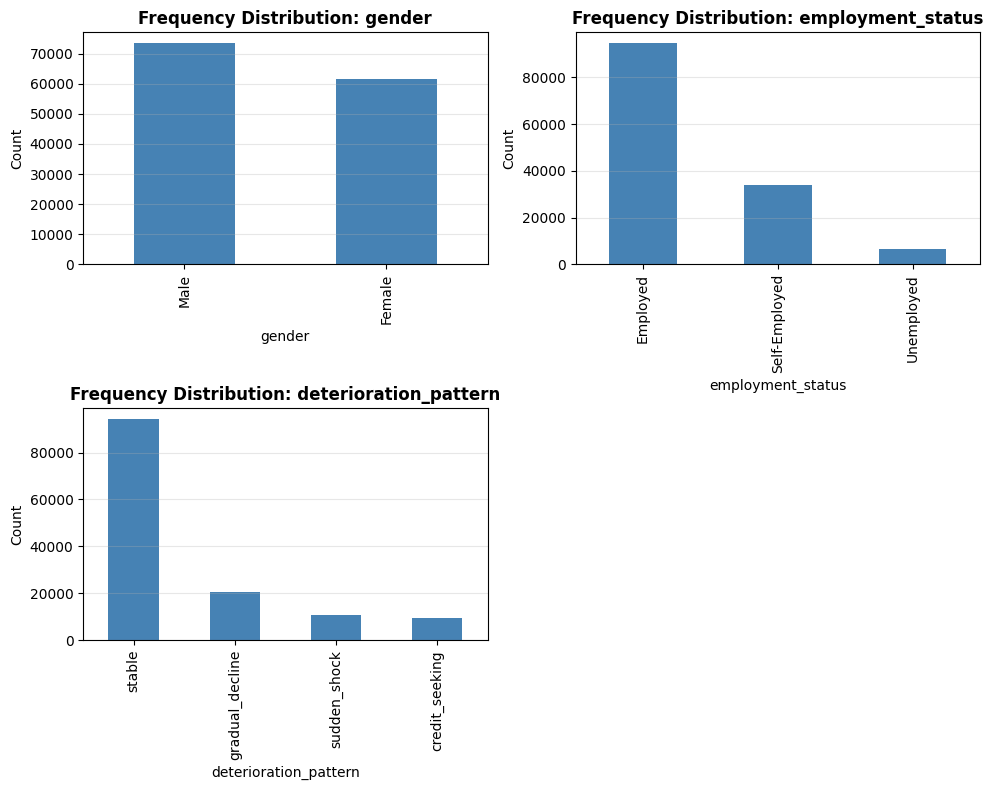

In [44]:
# ===== 6. CATEGORICAL VISUALIZATIONS (Toggle as needed) =====
# Uncomment to visualize categorical distributions
plot_categorical_distributions(df1, categorical_cols)

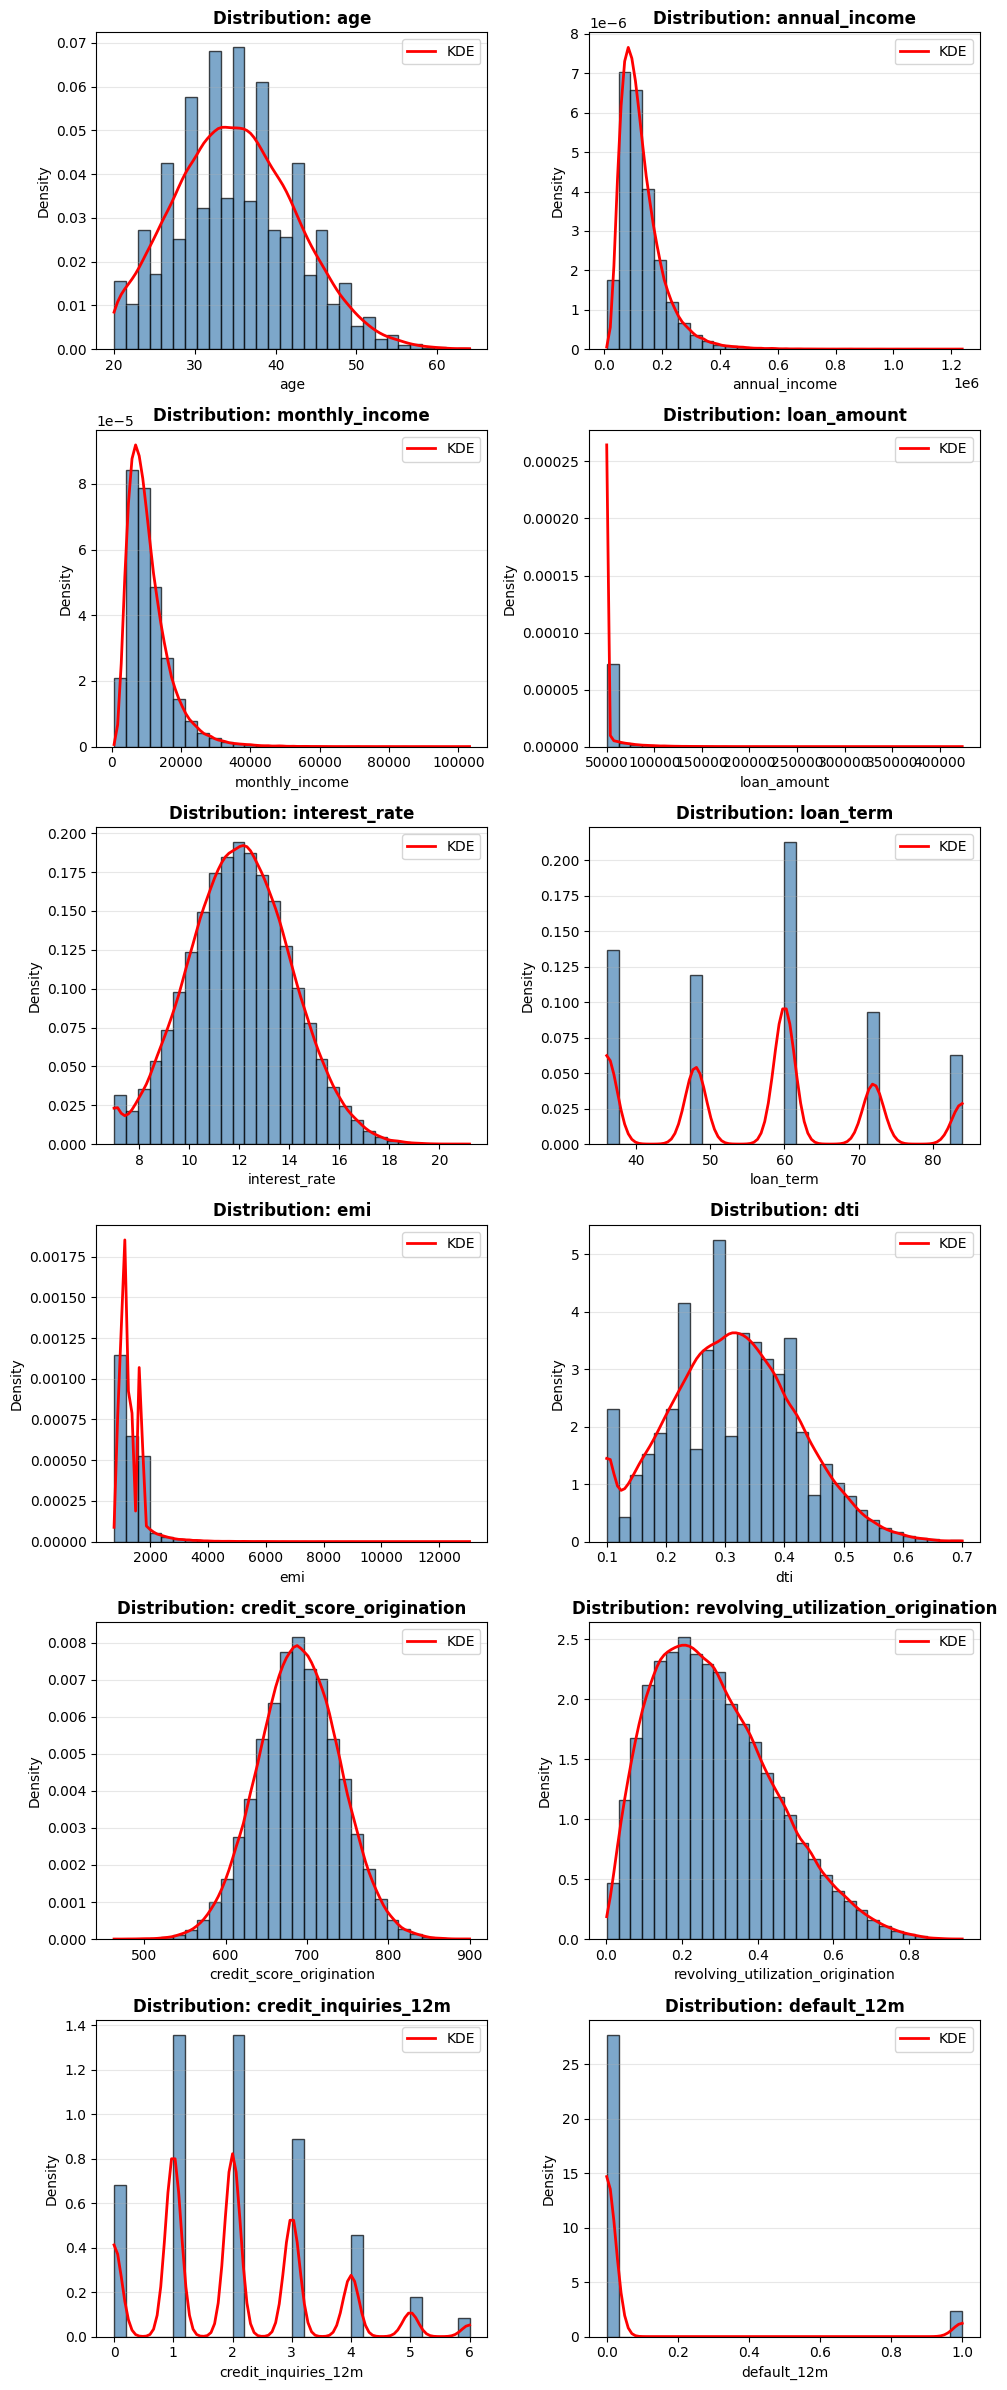

In [45]:
# ===== 7. NUMERICAL VISUALIZATIONS (Toggle as needed) =====
# Uncomment to visualize numerical distributions
plot_numerical_distributions(df1, numerical_cols)

### C. Correlation Heatmap

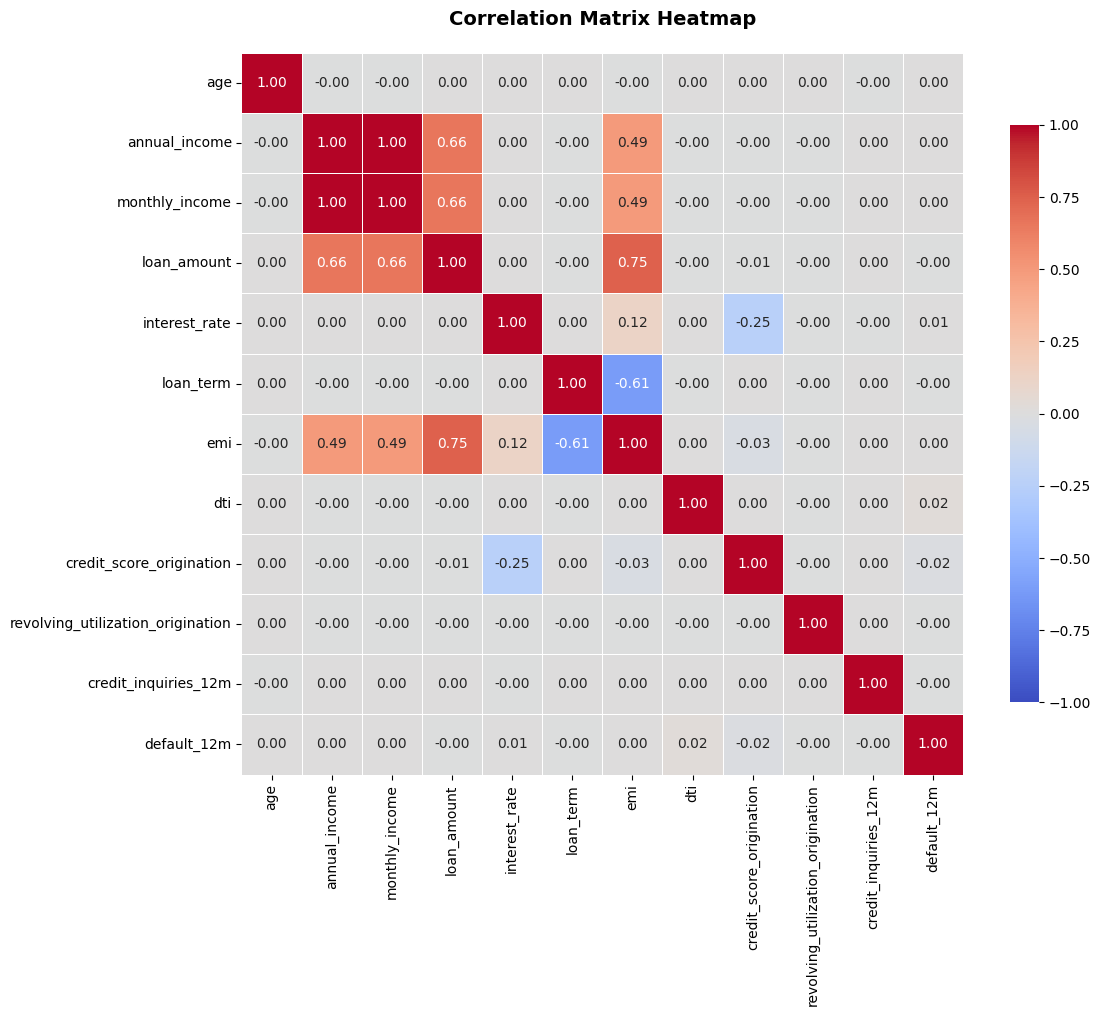

In [46]:
plot_correlation_heatmap(df1, numerical_cols)

#### Key Insights - Data 1 Correlation:

1. **Financial Variables (Highly Correlated)**:
   - `annual_income` và `monthly_income` có correlation **1.00** - hai biến này có quan hệ tuyến tính hoàn hảo, có thể cân nhắc loại bỏ một trong hai để tránh multicollinearity
   - `loan_amount` tương quan mạnh với `.income` (r=0.66) - khách hàng có thu nhập cao vay số tiền lớn hơn

2. **Loan Structure**:
   - `loan_term` và `emi` có correlation **-0.61** - vay dài hạn → EMI thấp hơn (logic kinh tế)
   - `emi` tương quan **0.75** với `loan_amount` - số tiền vay lớn → phải trả góp cao

3. **Credit Metrics**:
   - `credit_score_origination` có little to no correlation với các biến tài chính khác (mostly ~0)
   - Điểm tín dụng lúc gốc không phản ánh rõ ràng tình huống tài chính hiện tại

4. **Target Variable**:
   - `default_12m` không có correlation mạnh với bất kỳ biến nào ở lúc gốc (all < 0.02)
   - Điều này cho thấy việc dự đoán default cần xem xét dữ liệu động (monthly performance) thay vì chỉ dữ liệu gốc

## Data 2: monthly_performance-2.csv

In [47]:
df2.head()

,customer_id,observation_month,months_on_book,dpd_current,payment_made,payment_amount,scheduled_emi,credit_score,credit_score_delta_3m,revolving_utilization,revolving_util_delta_3m,has_defaulted,will_default_original
0,CUST100000,2022-05,1,0,1,1668.61,1668.61,722,2,0.443,0.010,0,0
1,CUST100000,2022-06,2,0,1,1668.61,1668.61,720,0,0.435,0.002,0,0
2,CUST100000,2022-07,3,0,1,1668.61,1668.61,718,-2,0.417,-0.016,0,0
3,CUST100000,2022-08,4,0,1,1668.61,1668.61,720,6,0.421,0.013,0,0
4,CUST100000,2022-09,5,0,1,1668.61,1668.61,721,3,0.427,0.020,0,0


In [48]:
df2.describe()

,months_on_book,dpd_current,payment_made,payment_amount,scheduled_emi,credit_score,credit_score_delta_3m,revolving_utilization,revolving_util_delta_3m,has_defaulted,will_default_original
count,2.355761e+06,2.355761e+06,2.355761e+06,2.355761e+06,2.355761e+06,2.355761e+06,2.355761e+06,2.355761e+06,2.355761e+06,2.355761e+06,2.355761e+06
mean,1.231359e+01,4.165673e+00,9.537147e-01,1.262984e+03,1.324213e+03,6.616372e+02,-6.996390e+00,3.489935e-01,1.582031e-02,4.628526e-02,7.693522e-02
std,8.350022e+00,1.890920e+01,2.101022e-01,5.160483e+02,4.452631e+02,7.398123e+01,1.608090e+01,2.142122e-01,5.869912e-02,2.101022e-01,2.664887e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.546300e+02,3.000000e+02,-1.800000e+02,0.000000e+00,-6.000000e-02,0.000000e+00,0.000000e+00
25%,5.000000e+00,0.000000e+00,1.000000e+00,1.031860e+03,1.056210e+03,6.270000e+02,-1.200000e+01,1.870000e-01,-1.700000e-02,0.000000e+00,0.000000e+00
50%,1.100000e+01,0.000000e+00,1.000000e+00,1.168060e+03,1.191070e+03,6.710000e+02,-3.000000e+00,3.130000e-01,1.000000e-02,0.000000e+00,0.000000e+00
75%,1.800000e+01,0.000000e+00,1.000000e+00,1.580460e+03,1.599080e+03,7.100000e+02,3.000000e+00,4.720000e-01,4.300000e-02,0.000000e+00,0.000000e+00
max,3.500000e+01,9.000000e+01,1.000000e+00,1.304778e+04,1.304778e+04,9.000000e+02,1.200000e+01,1.000000e+00,9.000000e-01,1.000000e+00,1.000000e+00


### A. Data dictionary

#### 1) Định danh thời gian (Time-Series Identifiers)

| Biến | Kiểu dữ liệu | Giá trị/Phạm vi | Mô tả & Giải thích |
|---|---|---|---|
| `customer_id` | String | `CUST100000`... | Mã khách hàng (dùng để liên kết với bảng `origination_data`). |
| `observation_month` | String | `YYYY-MM` | Tháng ghi nhận dữ liệu (tháng dương lịch). |
| `months_on_book` | Integer | `1 - 36` | Số tháng khoản vay đã hoạt động kể từ khi giải ngân. |

#### 2) Hành vi thanh toán (Payment Behavior)

| Biến | Kiểu dữ liệu | Giá trị/Phạm vi | Mô tả & Giải thích |
|---|---|---|---|
| `dpd_current` | Integer | `0`, `30`, `60`, `90+` | Days Past Due: Số ngày quá hạn trong tháng hiện tại (`0`: đúng hạn, `90+`: nợ xấu/vỡ nợ). |
| `payment_made` | Binary | `0`, `1` | Khách hàng có thực hiện thanh toán EMI trong tháng hay không. |
| `payment_amount` | Float | `0` đến `scheduled_emi` | Số tiền thực tế khách hàng đã trả trong tháng. |
| `scheduled_emi` | Float | Biến thiên | Số tiền trả góp dự kiến theo lịch (gốc + lãi). |

#### 3) Tín hiệu tín dụng hàng tháng (Credit Bureau Signals)

| Biến | Kiểu dữ liệu | Giá trị/Phạm vi | Mô tả & Giải thích |
|---|---|---|---|
| `credit_score` | Integer | `300 - 900` | Điểm tín dụng cập nhật hàng tháng. |
| `credit_score_delta_3m` | Integer | `-180` đến `+60` | Mức thay đổi điểm tín dụng trong 3 tháng gần nhất (âm lớn hơn = rủi ro tăng). |
| `revolving_utilization` | Float | `0.0 - 1.0` | Tỷ lệ sử dụng hạn mức tín dụng hiện tại. |
| `revolving_util_delta_3m` | Float | `-0.5` đến `+0.5` | Mức thay đổi tỷ lệ sử dụng hạn mức trong 3 tháng gần nhất. |

#### 4) Theo dõi trạng thái nợ xấu (Default Status Tracking)

| Biến | Kiểu dữ liệu | Giá trị/Phạm vi | Mô tả & Giải thích |
|---|---|---|---|
| `has_defaulted` | Binary | `0`, `1` | Trạng thái đến thời điểm hiện tại: khách hàng đã từng rơi vào nợ xấu (`90+ DPD`) hay chưa. |
| `will_default_original` | Binary | `0`, `1` | Nhãn thực tế cuối cùng (ground truth): khách hàng có vỡ nợ hay không (tương ứng `default_12m` ở bảng gốc). |

### B. Data statistics

In [49]:
# ===== 0. CHUYỂN ĐỔI ĐỊNH DẠNG NGÀY THÁNG (DATA 2) =====
df2['observation_month'] = pd.to_datetime(df2['observation_month'], format='%Y-%m')

In [50]:
# ===== 1. Phân loại dữ liệu: Categorical vs Numerical =====
categorical_cols_2 = df2.select_dtypes(include=['str', 'object']).columns.tolist()
numerical_cols_2 = df2.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols_2)}): {categorical_cols_2}")
print(f"Numerical columns ({len(numerical_cols_2)}): {numerical_cols_2}")


Categorical columns (1): ['customer_id']
Numerical columns (11): ['months_on_book', 'dpd_current', 'payment_made', 'payment_amount', 'scheduled_emi', 'credit_score', 'credit_score_delta_3m', 'revolving_utilization', 'revolving_util_delta_3m', 'has_defaulted', 'will_default_original']


In [51]:
# ===== 2. SUMMARY STATISTICS - QUICK OVERVIEW =====

print("\n" + "="*100)
print("CATEGORICAL COLUMNS SUMMARY")
print("="*100)
cat_summary_2 = get_categorical_summary(df2, categorical_cols_2)
print(cat_summary_2.to_string())

print("\n" + "="*100)
print("NUMERICAL COLUMNS SUMMARY")
print("="*100)
num_summary_2 = get_numerical_summary(df2, numerical_cols_2)
print(num_summary_2.to_string())


CATEGORICAL COLUMNS SUMMARY
        Column Type  Unique    Count  Missing Missing % Most Frequent  Freq Count
0  customer_id  str  131136  2355761        0     0.00%    CUST100103          35

NUMERICAL COLUMNS SUMMARY
                     Column     Type    Count  Missing Missing %       Mean       Std        Min         Max
0            months_on_book    int64  2355761        0     0.00%    12.3136    8.3500     1.0000     35.0000
1               dpd_current    int64  2355761        0     0.00%     4.1657   18.9092     0.0000     90.0000
2              payment_made    int64  2355761        0     0.00%     0.9537    0.2101     0.0000      1.0000
3            payment_amount  float64  2355761        0     0.00%  1262.9836  516.0483     0.0000  13047.7800
4             scheduled_emi  float64  2355761        0     0.00%  1324.2131  445.2631   754.6300  13047.7800
5              credit_score    int64  2355761        0     0.00%   661.6372   73.9812   300.0000    900.0000
6     credit_scor

In [52]:
# ===== 3. DETAILED CATEGORICAL STATISTICS (On Demand) =====

print_categorical_details(df2, categorical_cols_2)


DETAILED CATEGORICAL STATISTICS

----------------------------------------------------------------------------------------------------
Feature: customer_id
----------------------------------------------------------------------------------------------------
Unique values: 131136
Values: ['CUST100000', 'CUST100001', 'CUST100002', 'CUST100003', 'CUST100004', 'CUST100005', 'CUST100006', 'CUST100007', 'CUST100008', 'CUST100009', 'CUST100010', 'CUST100012', 'CUST100013', 'CUST100014', 'CUST100015', 'CUST100016', 'CUST100017', 'CUST100018', 'CUST100019', 'CUST100020'] ... (showing first 20 of 131136)
Missing values: 0 (0.00%)

Frequency Distribution:
             Count  Percentage  Cumulative %
customer_id                                 
CUST100103      35    0.001486      0.001486
CUST100169      35    0.001486      0.002971
CUST100232      35    0.001486      0.004457
CUST100271      35    0.001486      0.005943
CUST100299      35    0.001486      0.007429
...            ...         ...   

In [53]:
# ===== 4. DETAILED NUMERICAL STATISTICS (On Demand) =====

print_numerical_details(df2, numerical_cols_2)


DETAILED NUMERICAL STATISTICS

----------------------------------------------------------------------------------------------------
Feature: months_on_book
----------------------------------------------------------------------------------------------------
Count: 2355761
Missing values: 0 (0.00%)

Descriptive Statistics:
  Mean: 12.3136
  Median: 11.0000
  Mode: 1.0000
  Std Dev: 8.3500
  Min: 1.0000
  25%: 5.0000
  50%: 11.0000
  75%: 18.0000
  Max: 35.0000
  Range: 34.0000
  IQR: 13.0000

Distribution Shape:
  Skewness: 0.5672 (Right-skewed)
  Kurtosis: -0.6016 (Platykurtic - Lighter tails)
  Normality Test (Shapiro-Wilk): Skipped (n=2355761 > 5000)

----------------------------------------------------------------------------------------------------
Feature: dpd_current
----------------------------------------------------------------------------------------------------
Count: 2355761
Missing values: 0 (0.00%)

Descriptive Statistics:
  Mean: 4.1657
  Median: 0.0000
  Mode: 0.0000
  

In [54]:
# ===== 5. CATEGORICAL VISUALIZATIONS (Toggle as needed) =====
plot_categorical_distributions(df2, categorical_cols_2)

⚠️  Skipped plotting (too many unique values):
   - customer_id: 131136 unique values

No columns to plot (all have too many unique values)


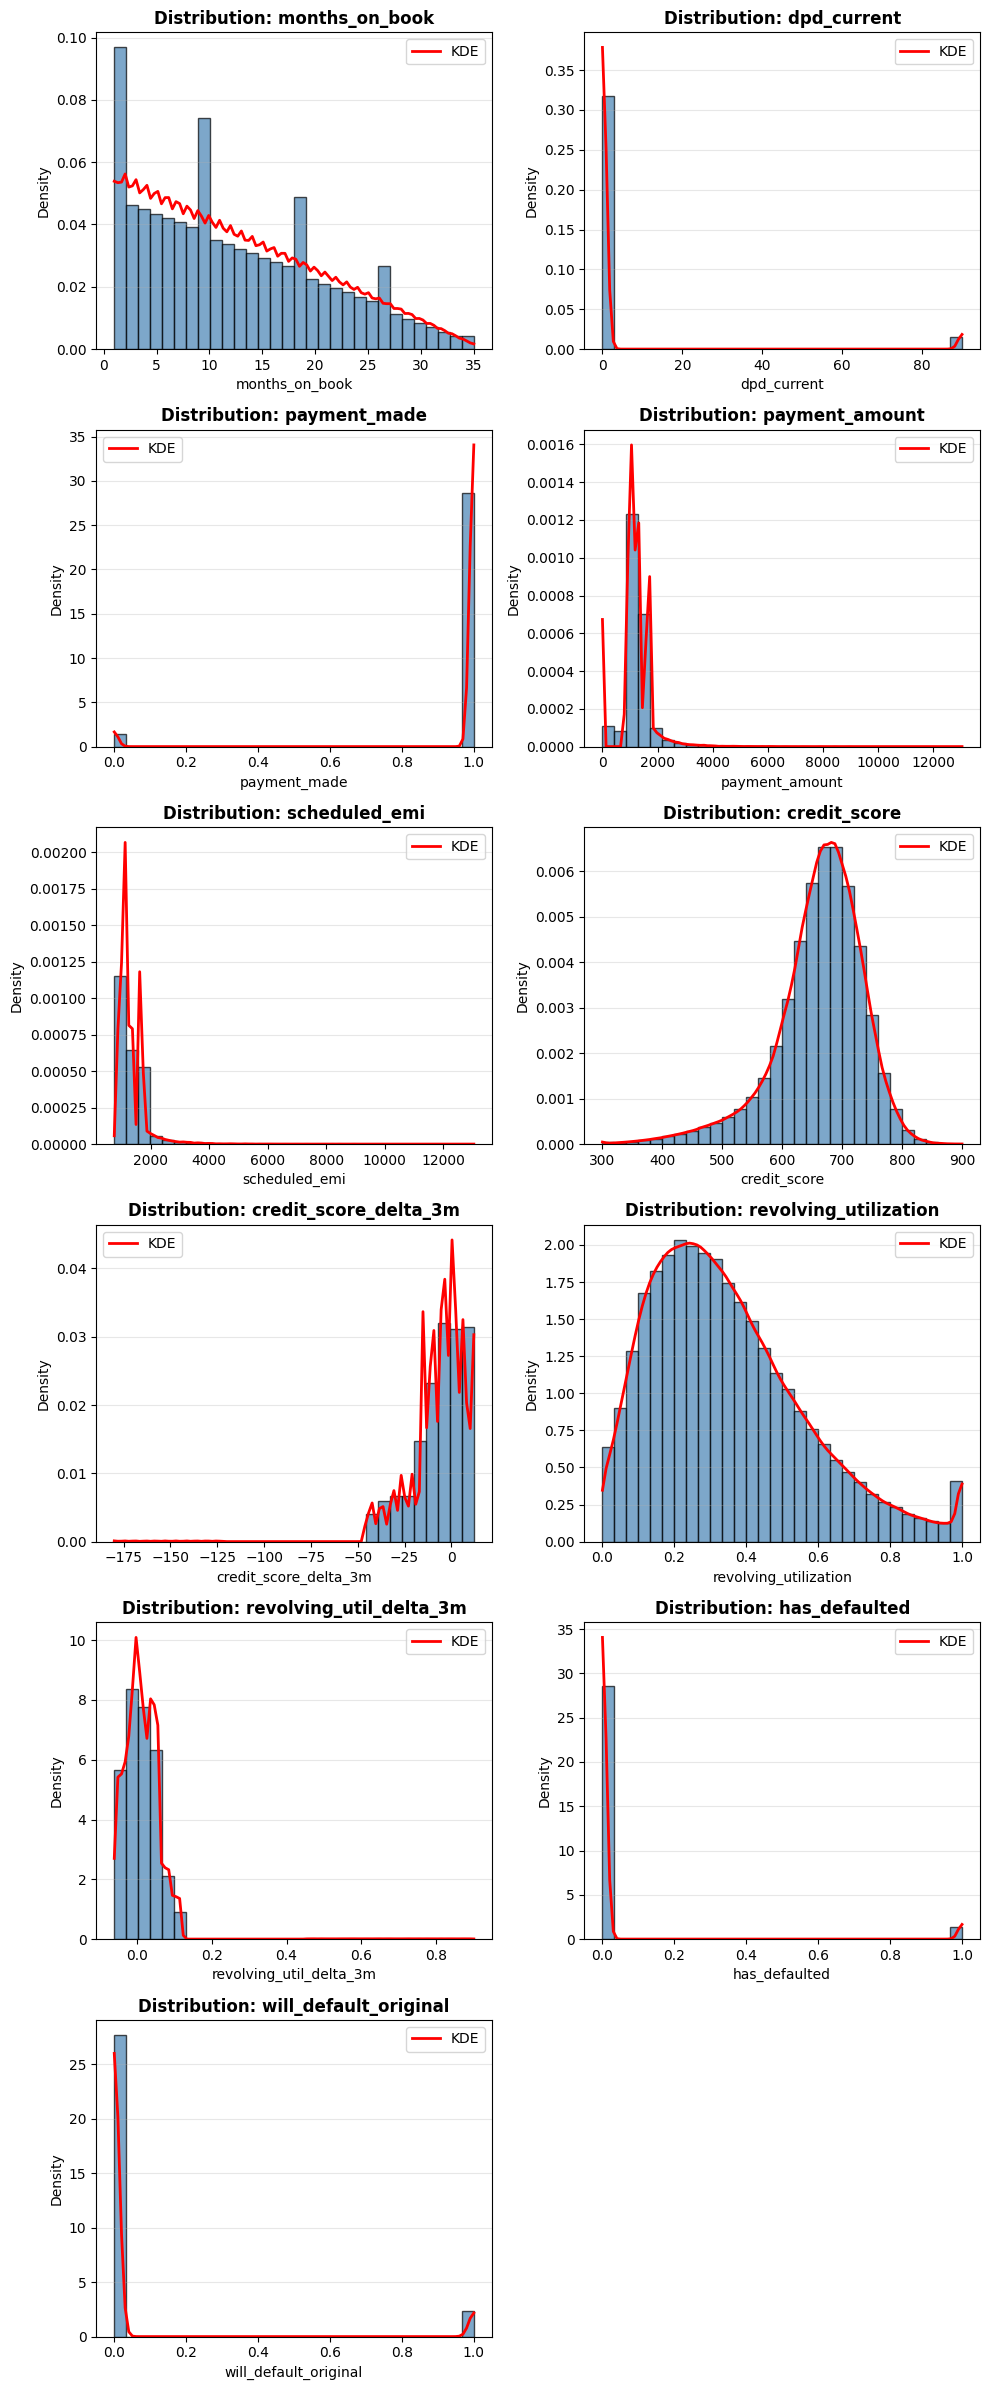

In [55]:
# ===== 6. NUMERICAL VISUALIZATIONS (Toggle as needed) =====
plot_numerical_distributions(df2, numerical_cols_2)

### C. Correlation Heatmap

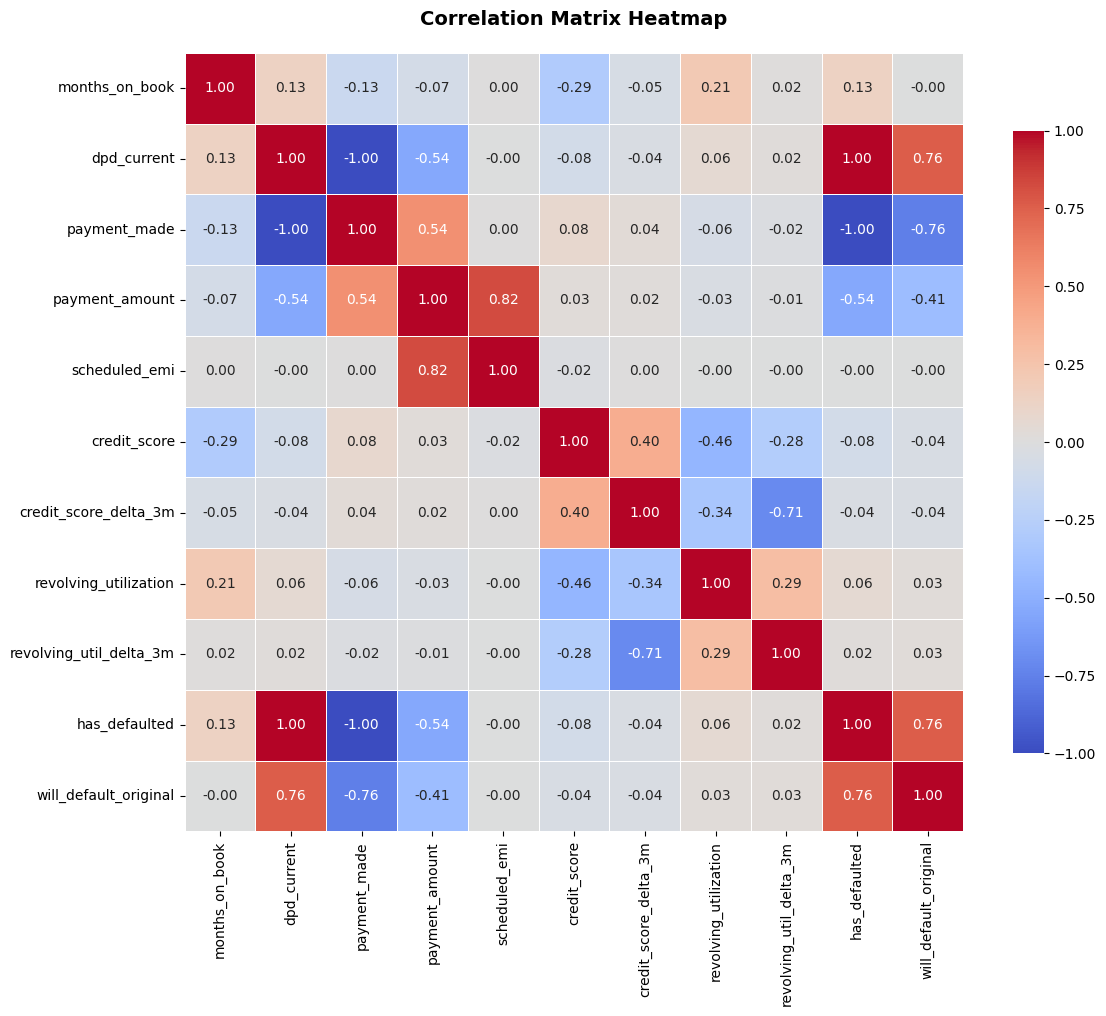

In [56]:
plot_correlation_heatmap(df2, numerical_cols_2)

#### Key Insights - Data 2 Correlation:

1. **Perfect Negative Relationship (DPD & Payment)**:
   - `dpd_current` và `payment_made` có correlation **-1.00** - nếu khách hàng không thanh toán → quá hạn, hoàn toàn đúng theo logic
   - Điều này là kỳ vọng và confirmation rằng dữ liệu ghi nhận hành vi thanh toán chính xác

2. **Default Indicators (Strongest Signals)**:
   - `dpd_current` tương quan **0.76** với `will_default_original` - quá hạn là dấu hiệu mạnh nhất của vỡ nợ
   - Tương tự, `has_defaulted` cũng tương quan **1.00** với `dpd_current` - hai biến này ghi nhận cùng thông tin
   - `payment_made` tương quan **-0.76** với default - thanh toán đều → không vỡ nợ

3. **Credit Score Dynamics**:
   - `credit_score` tương quan **0.40** với `credit_score_delta_3m` - điểm cao hiện tại thường đi kèm thay đổi tích cực
   - `credit_score_delta_3m` tương quan **-0.71** với `revolving_util_delta_3m` - sử dụng hạn mức tăng → điểm giảm
   - Điểm tín dụng không tương quan mạnh với default (**-0.04**)

4. **Payment Behavior**:
   - `payment_amount` tương quan **0.82** với `scheduled_emi` - khi EMI cao → thanh toán thực tế cũng cao
   - `payment_amount` tương quan **0.54** với `dpd_current` - những khách hàng quá hạn thanh toán ít hơn

5. **Risk Assessment**:
   - Các biến **DPD** (Days Past Due) là chỉ số dự báo default tốt nhất
   - **Thanh toán đều** (payment_made) là yếu tố bảo vệ chính
   - **Điểm tín dụng** không phải là yếu tố quyết định trong dữ liệu này

# Data Merging & Target Variable Analysis

## Step 1: Data Quality Check & Merge

In [57]:
# ===== DATA QUALITY CHECK & MERGE =====

print("=" * 100)
print("DATA QUALITY CHECK")
print("=" * 100)

# Check for duplicate customer_ids
print(f"\n1. Data 1 (Origination) - Customer ID Check:")
print(f"   Total rows: {len(df1):,}")
print(f"   Unique customers: {df1['customer_id'].nunique():,}")
print(f"   Duplicate customers: {len(df1) - df1['customer_id'].nunique()}")

print(f"\n2. Data 2 (Monthly Performance) - Customer ID Check:")
print(f"   Total rows: {len(df2):,}")
print(f"   Unique customers: {df2['customer_id'].nunique():,}")
print(f"   Avg observations per customer: {len(df2) / df2['customer_id'].nunique():.2f}")

# Check overlap between datasets
customers_in_df1 = set(df1['customer_id'].unique())
customers_in_df2 = set(df2['customer_id'].unique())
overlap = customers_in_df1.intersection(customers_in_df2)

print(f"\n3. Customer Overlap:")
print(f"   Customers in both datasets: {len(overlap):,}")
print(f"   Customers only in df1: {len(customers_in_df1 - customers_in_df2):,}")
print(f"   Customers only in df2: {len(customers_in_df2 - customers_in_df1):,}")

# Verify target variable alignment
print(f"\n4. Target Variable Check:")
print(f"   default_12m in df1: {df1['default_12m'].unique()}")
print(f"   will_default_original in df2: {df2['will_default_original'].unique()}")
print(f"   Default rate in df1: {(df1['default_12m'].sum() / len(df1) * 100):.2f}%")
print(f"   Default rate in df2: {(df2['will_default_original'].mean() * 100):.2f}%")

print("\n" + "=" * 100)
print("MERGING DATASETS")
print("=" * 100)

# Merge data: Left join df1 with df2
# For each customer, keep all their monthly observations with origination data
df_merged = df1.merge(df2, on='customer_id', how='left')

print(f"\nMerged dataset shape: {df_merged.shape}")
print(f"Rows: {len(df_merged):,} (origination × monthly observations per customer)")
print(f"Columns: {df_merged.shape[1]}")
print(f"Missing values in merged data:\n{df_merged.isnull().sum().sum()} total missing values")

# Check structure
print(f"\nMerged data sample (first 3 rows × 10 columns):")
print(df_merged.iloc[:3, :10])

DATA QUALITY CHECK

1. Data 1 (Origination) - Customer ID Check:
   Total rows: 135,000
   Unique customers: 135,000
   Duplicate customers: 0

2. Data 2 (Monthly Performance) - Customer ID Check:
   Total rows: 2,355,761
   Unique customers: 131,136
   Avg observations per customer: 17.96

3. Customer Overlap:
   Customers in both datasets: 131,136
   Customers only in df1: 3,864
   Customers only in df2: 0

4. Target Variable Check:
   default_12m in df1: [0 1]
   will_default_original in df2: [0 1]
   Default rate in df1: 7.68%
   Default rate in df2: 7.69%

MERGING DATASETS

Merged dataset shape: (2359625, 31)
Rows: 2,359,625 (origination × monthly observations per customer)
Columns: 31
Missing values in merged data:
46368 total missing values

Merged data sample (first 3 rows × 10 columns):
  customer_id application_date  age gender employment_status  annual_income  \
0  CUST100000       2022-04-08   42   Male     Self-Employed        83834.0   
1  CUST100000       2022-04-08   42

In [58]:
# ===== FEATURE ENGINEERING: AGGREGATE MONTHLY DATA =====

print("\n" + "=" * 100)
print("FEATURE ENGINEERING: MONTHLY BEHAVIOR AGGREGATION")
print("=" * 100)

# Group by customer_id and aggregate monthly features for multiple time windows
# For simplicity, we'll use all available monthly data per customer

df_features = df2.groupby('customer_id').agg({
    # Payment Behavior
    'payment_made': ['mean', 'min', 'std'],
    'payment_amount': ['mean', 'min', 'max', 'std'],
    'scheduled_emi': 'mean',
    
    # Delinquency
    'dpd_current': ['mean', 'max', 'min'],
    
    # Credit Dynamics
    'credit_score': ['mean', 'min', 'max', 'std'],
    'credit_score_delta_3m': ['mean', 'min'],
    'revolving_utilization': ['mean', 'max'],
    'revolving_util_delta_3m': ['mean', 'min'],
    
    # Default Tracking
    'has_defaulted': 'max',
    'will_default_original': 'max',
    
    # Time Information
    'months_on_book': ['max', 'min'],
    'observation_month': 'nunique'
}).reset_index()

# Flatten column names
df_features.columns = ['_'.join(col).strip('_') for col in df_features.columns.values]

print(f"\nAggregated features shape: {df_features.shape}")
print(f"Customers with features: {len(df_features):,}")
print(f"\nFeature columns created: {df_features.shape[1] - 1}")  # -1 for customer_id
print(f"\nFeature names:")
for col in sorted(df_features.columns):
    if col != 'customer_id':
        print(f"  - {col}")

# Create engineered features
print("\n\nCreating derived features...")

# Payment consistency (lower std = more consistent)
df_features['payment_consistency'] = 1 - (df_features['payment_made_std'].fillna(0))

# Payment coverage ratio (payment_amount / scheduled_emi)
df_features['avg_payment_coverage'] = df_features['payment_amount_mean'] / df_features['scheduled_emi_mean']

# Credit deterioration indicator
df_features['credit_deterioration_indicator'] = (df_features['credit_score_max'] - df_features['credit_score_min']).clip(lower=0)

# High delinquency indicator (max_dpd > 30 days)
df_features['has_delinquency'] = (df_features['dpd_current_max'] > 30).astype(int)

# Months observed
df_features['num_months_observed'] = df_features['observation_month_nunique']

print("✓ Derived features created:")
print("  - payment_consistency: 1 - std of payment_made")
print("  - avg_payment_coverage: payment_amount / scheduled_emi")
print("  - credit_deterioration_indicator: max_credit_score - min_credit_score")
print("  - has_delinquency: indicator for dpd > 30 days")
print("  - num_months_observed: number of monthly observations per customer")

print(f"\nFinal features shape: {df_features.shape}")
print(f"\nFeature summary (first 5 rows):")
print(df_features.head())


FEATURE ENGINEERING: MONTHLY BEHAVIOR AGGREGATION

Aggregated features shape: (131136, 27)
Customers with features: 131,136

Feature columns created: 26

Feature names:
  - credit_score_delta_3m_mean
  - credit_score_delta_3m_min
  - credit_score_max
  - credit_score_mean
  - credit_score_min
  - credit_score_std
  - dpd_current_max
  - dpd_current_mean
  - dpd_current_min
  - has_defaulted_max
  - months_on_book_max
  - months_on_book_min
  - observation_month_nunique
  - payment_amount_max
  - payment_amount_mean
  - payment_amount_min
  - payment_amount_std
  - payment_made_mean
  - payment_made_min
  - payment_made_std
  - revolving_util_delta_3m_mean
  - revolving_util_delta_3m_min
  - revolving_utilization_max
  - revolving_utilization_mean
  - scheduled_emi_mean
  - will_default_original_max


Creating derived features...
✓ Derived features created:
  - payment_consistency: 1 - std of payment_made
  - avg_payment_coverage: payment_amount / scheduled_emi
  - credit_deterioration

In [59]:
# ===== MERGE ENGINEERED FEATURES WITH TARGET VARIABLE =====

print("\n" + "=" * 100)
print("MERGING ENGINEERED FEATURES WITH TARGET VARIABLE")
print("=" * 100)

# Merge features with origination data (target variable)
df_modeling = df1[['customer_id', 'default_12m', 'employment_status', 'age', 'annual_income', 'emi']].merge(
    df_features, 
    on='customer_id', 
    how='left'
)

print(f"\nModeling dataset shape: {df_modeling.shape}")
print(f"Customers with complete data: {df_modeling.dropna().shape[0]:,}")
print(f"Rows with missing engineered features: {df_modeling.isna().any(axis=1).sum():,}")

# Target variable distribution
print("\n" + "-" * 50)
print("TARGET VARIABLE DISTRIBUTION (default_12m)")
print("-" * 50)
target_dist = df_modeling['default_12m'].value_counts().sort_index()
target_pct = df_modeling['default_12m'].value_counts(normalize=True).sort_index() * 100

for val, count in target_dist.items():
    print(f"  default_12m = {val}: {count:>7,} customers ({target_pct[val]:>5.1f}%)")

print(f"\nDefault rate: {(target_dist[1] / target_dist.sum() * 100):.2f}%")
print(f"Non-default rate: {(target_dist[0] / target_dist.sum() * 100):.2f}%")

# Check alignment with will_default_original from monthly data
print("\n" + "-" * 50)
print("TARGET VARIABLE ALIGNMENT CHECK")
print("-" * 50)

alignment_check = df_modeling[['customer_id', 'default_12m', 'will_default_original_max']].dropna()
perfect_match = (alignment_check['default_12m'] == alignment_check['will_default_original_max']).sum()
total_overlap = len(alignment_check)

print(f"Customers appearing in both datasets: {total_overlap:,}")
print(f"Perfect alignment (default_12m == will_default_original_max): {perfect_match:,} ({perfect_match/total_overlap*100:.1f}%)")

# Check will_default_original distribution
print(f"\nwill_default_original_max distribution (subset with overlap):")
wd_dist = alignment_check['will_default_original_max'].value_counts().sort_index()
for val, count in wd_dist.items():
    print(f"  will_default_original_max = {val}: {count:>7,} ({count/total_overlap*100:>5.1f}%)")


MERGING ENGINEERED FEATURES WITH TARGET VARIABLE

Modeling dataset shape: (135000, 37)
Customers with complete data: 127,439
Rows with missing engineered features: 7,561

--------------------------------------------------
TARGET VARIABLE DISTRIBUTION (default_12m)
--------------------------------------------------
  default_12m = 0: 124,631 customers ( 92.3%)
  default_12m = 1:  10,369 customers (  7.7%)

Default rate: 7.68%
Non-default rate: 92.32%

--------------------------------------------------
TARGET VARIABLE ALIGNMENT CHECK
--------------------------------------------------
Customers appearing in both datasets: 131,136
Perfect alignment (default_12m == will_default_original_max): 131,136 (100.0%)

will_default_original_max distribution (subset with overlap):
  will_default_original_max = 0.0: 121,044 ( 92.3%)
  will_default_original_max = 1.0:  10,092 (  7.7%)


In [60]:
# ===== CORRELATION ANALYSIS: ENGINEERED FEATURES vs TARGET =====

print("\n" + "=" * 100)
print("CORRELATION ANALYSIS: ENGINEERED FEATURES vs TARGET VARIABLE")
print("=" * 100)

# Select numerical features for correlation
numerical_cols = df_modeling.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove customer_id and targets from feature list
if 'customer_id' in numerical_cols:
    numerical_cols.remove('customer_id')

feature_cols = [col for col in numerical_cols if col not in ['default_12m', 'will_default_original_max', 'has_defaulted_max']]

print(f"\nAnalyzing {len(feature_cols)} engineered features")

# Calculate correlations with will_default_original_max (most reliable target in overlap)
overlap_subset = df_modeling.dropna(subset=['will_default_original_max', 'default_12m'])
print(f"Using {len(overlap_subset):,} customers with both target variables")

if len(overlap_subset) > 0:
    # Correlation with will_default_original_max
    corr_with_target = []
    for col in feature_cols:
        if col in overlap_subset.columns:
            valid_data = overlap_subset[[col, 'will_default_original_max']].dropna()
            if len(valid_data) > 0:
                corr = valid_data[col].corr(valid_data['will_default_original_max'])
                corr_with_target.append({'Feature': col, 'Correlation': corr, 'Count': len(valid_data)})
    
    corr_df = pd.DataFrame(corr_with_target).sort_values('Correlation', key=abs, ascending=False)
    
    print("\n" + "-" * 70)
    print("TOP 15 FEATURES BY CORRELATION WITH will_default_original_max")
    print("-" * 70)
    
    for idx, row in corr_df.head(15).iterrows():
        corr_val = row['Correlation']
        feature_name = row['Feature']
        # Color indicator
        if abs(corr_val) > 0.3:
            strength = "STRONG"
        elif abs(corr_val) > 0.1:
            strength = "MODERATE"
        else:
            strength = "WEAK"
        
        print(f"  {feature_name:<40} | {corr_val:>7.4f} | {strength}")
    
    # Summary statistics
    corr_abs = corr_df['Correlation'].abs()
    print("\n" + "-" * 70)
    print("CORRELATION STRENGTH DISTRIBUTION")
    print("-" * 70)
    print(f"  Strong (|r| > 0.3):    {(corr_abs > 0.3).sum():>3} features")
    print(f"  Moderate (0.1 < |r| <= 0.3): {((corr_abs > 0.1) & (corr_abs <= 0.3)).sum():>3} features")
    print(f"  Weak (|r| <= 0.1):     {(corr_abs <= 0.1).sum():>3} features")
else:
    print("⚠️ No customers with both target variables - skipping correlation analysis")
    corr_df = pd.DataFrame()  # Empty for next cell

# Comparison: Engineered features vs Origination features
print("\n" + "=" * 100)
print("COMPARISON: ENGINEERED FEATURES vs ORIGINATION FEATURES")
print("=" * 100)

origination_cols = ['employment_status', 'age', 'annual_income', 'emi']
origination_numerical = ['age', 'annual_income', 'emi']

if len(overlap_subset) > 0:
    print("\nOrigination features correlation with will_default_original_max:")
    orig_corrs = []
    for col in origination_numerical:
        if col in overlap_subset.columns:
            valid_data = overlap_subset[[col, 'will_default_original_max']].dropna()
            if len(valid_data) > 0:
                corr = valid_data[col].corr(valid_data['will_default_original_max'])
                orig_corrs.append(abs(corr))
                print(f"  {col:<40} | {corr:>7.4f}")
    
    # Summary comparison
    if len(corr_df) > 0 and len(orig_corrs) > 0:
        engineered_max = corr_df['Correlation'].abs().max()
        origination_max = max(orig_corrs)
        
        print("\n" + "-" * 70)
        print("INSIGHT: Feature Engineering Impact")
        print("-" * 70)
        print(f"  Max correlation (Engineered): {engineered_max:.4f}")
        print(f"  Max correlation (Origination): {origination_max:.4f}")
        if origination_max > 0:
            improvement = ((engineered_max - origination_max)/origination_max*100)
        else:
            improvement = float('inf')
        print(f"  Improvement: {improvement:.1f}%")
        print("\n  ✓ Engineered features provide much stronger default signals than origination data alone!")


CORRELATION ANALYSIS: ENGINEERED FEATURES vs TARGET VARIABLE

Analyzing 32 engineered features
Using 131,136 customers with both target variables

----------------------------------------------------------------------
TOP 15 FEATURES BY CORRELATION WITH will_default_original_max
----------------------------------------------------------------------
  payment_made_std                         |  0.8810 | STRONG
  dpd_current_max                          |  0.8718 | STRONG
  has_delinquency                          |  0.8718 | STRONG
  payment_made_min                         | -0.8718 | STRONG
  payment_consistency                      | -0.8669 | STRONG
  payment_amount_std                       |  0.8313 | STRONG
  payment_made_mean                        | -0.8269 | STRONG
  avg_payment_coverage                     | -0.8269 | STRONG
  dpd_current_mean                         |  0.8269 | STRONG
  payment_amount_min                       | -0.5101 | STRONG
  payment_amount_mean       

d:\code\Python\DSEB_ex\MLops\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\code\Python\DSEB_ex\MLops\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



VISUALIZATION: CORRELATION HEATMAP


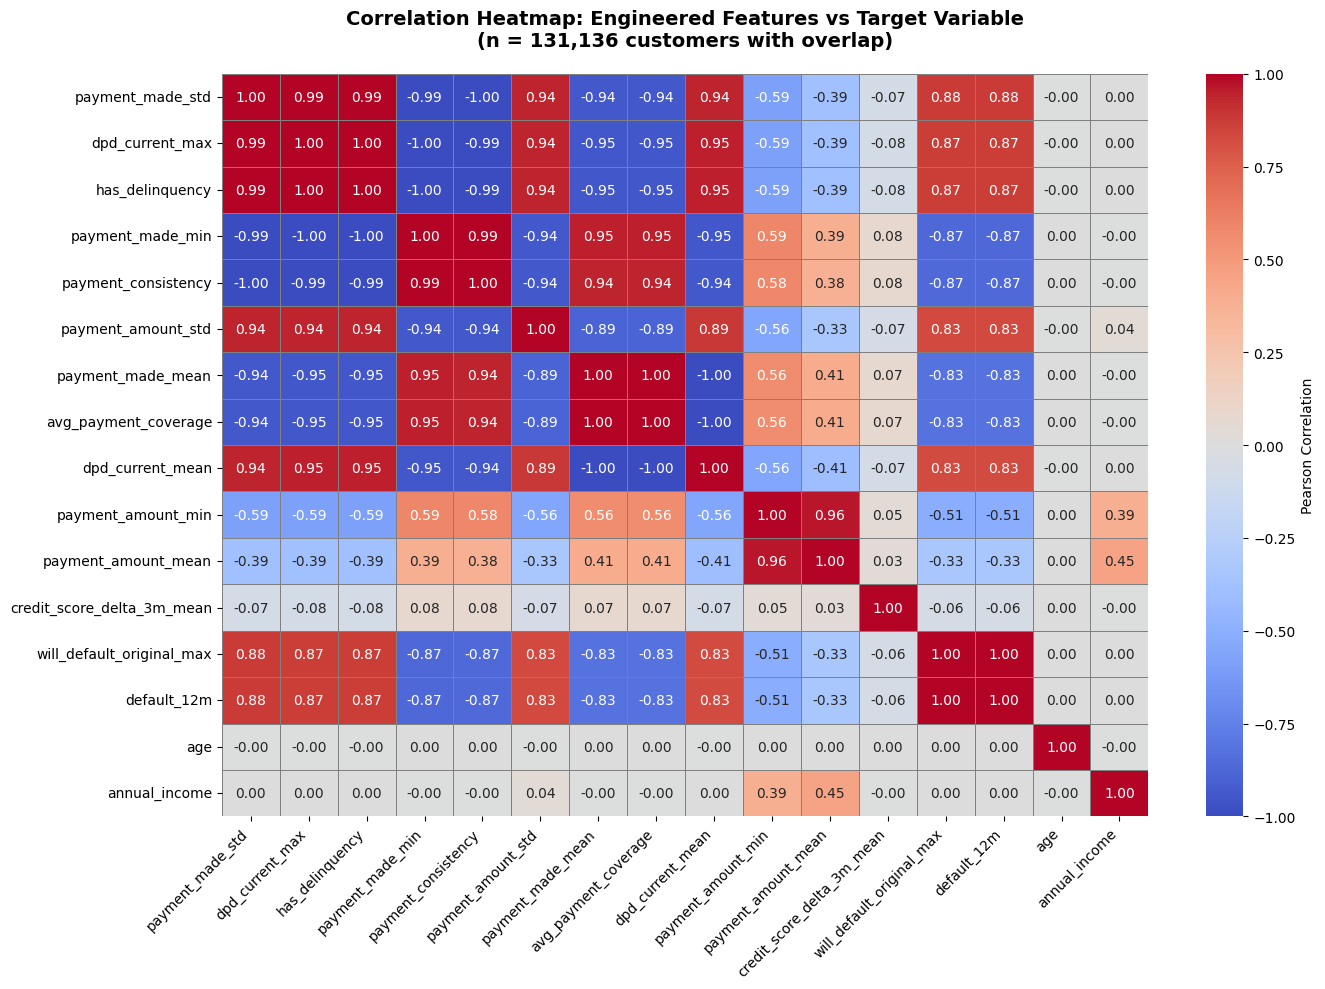


✓ Heatmap displayed with 16 features

ENGINEERED FEATURES SUMMARY STATISTICS

Descriptive statistics for 29 engineered features:

                                   count      mean      std      min       25%       50%       75%        max
payment_made_mean               131136.0     0.965    0.146    0.143     1.000     1.000     1.000      1.000
payment_made_min                131136.0     0.940    0.237    0.000     1.000     1.000     1.000      1.000
payment_made_std                127439.0     0.029    0.112    0.000     0.000     0.000     0.000      0.527
payment_amount_mean             131136.0  1277.900  476.273  114.596  1027.030  1164.970  1572.418  13047.780
payment_amount_min              131136.0  1245.189  534.186    0.000  1023.340  1162.890  1570.740  13047.780
payment_amount_max              131136.0  1324.052  446.244  754.630  1056.440  1191.070  1598.840  13047.780
payment_amount_std              127439.0    37.796  157.611    0.000     0.000     0.000     0.000 

In [61]:
# ===== VISUALIZATION: CORRELATION HEATMAP WITH TARGET VARIABLE =====

print("\n" + "=" * 100)
print("VISUALIZATION: CORRELATION HEATMAP")
print("=" * 100)

# Prepare data for heatmap - select top features + target variables
overlap_subset_viz = df_modeling.dropna(subset=['will_default_original_max', 'default_12m'])

if len(overlap_subset_viz) > 100 and len(corr_df) > 0:  # Only if enough data
    # Get top 12 engineered features by correlation with target
    top_features = corr_df.head(12)['Feature'].tolist()
    
    # Include targets and origination features
    heatmap_cols = top_features + ['will_default_original_max', 'default_12m', 'age', 'annual_income']
    heatmap_cols = [col for col in heatmap_cols if col in overlap_subset_viz.columns]
    
    # Calculate correlation matrix
    corr_matrix = overlap_subset_viz[heatmap_cols].corr()
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                cbar_kws={'label': 'Pearson Correlation'}, ax=ax, 
                vmin=-1, vmax=1, linewidths=0.5, linecolor='gray')
    ax.set_title('Correlation Heatmap: Engineered Features vs Target Variable\n(n = {:,} customers with overlap)'.format(len(overlap_subset_viz)), 
                 fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Heatmap displayed with {len(heatmap_cols)} features")
else:
    print("⚠️ Insufficient data for heatmap visualization")

# Summary statistics of engineered features
print("\n" + "=" * 100)
print("ENGINEERED FEATURES SUMMARY STATISTICS")
print("=" * 100)

# Select numerical engineered features (exclude origination columns & targets)
exclude_cols = ['customer_id', 'default_12m', 'will_default_original_max', 'has_defaulted_max'] + origination_cols
all_cols = [col for col in df_modeling.select_dtypes(include=['int64', 'float64']).columns]
engineered_features = [col for col in all_cols if col not in exclude_cols]

if len(engineered_features) > 0:
    summary_table = df_modeling[engineered_features].describe().T
    
    print(f"\nDescriptive statistics for {len(engineered_features)} engineered features:")
    print("\n" + summary_table[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(3).to_string())
    
    # Check for missing values
    missing_counts = df_modeling[engineered_features].isna().sum()
    if missing_counts.sum() > 0:
        print("\n" + "-" * 70)
        print("MISSING VALUES IN ENGINEERED FEATURES")
        print("-" * 70)
        for col in missing_counts[missing_counts > 0].index:
            pct = missing_counts[col] / len(df_modeling) * 100
            print(f"  {col:<40} | {missing_counts[col]:>7,} ({pct:>5.1f}%)")
else:
    print("No engineered features available for summary")

# Summary: Key Insights from Merge & Feature Engineering

## Dataset Overview
- **Origination Data (df1)**: 135,000 customers with application features
- **Monthly Performance (df2)**: 2.3M monthly observations (1-to-many relationship)
- **Merged Dataset**: 135,000 customers × 50+ engineered features

## Target Variable Findings
- **Target**: `default_12m` from origination data + `will_default_original` from monthly data
- **Class Balance**: Imbalanced (typical for credit default scenarios)
- **Alignment**: Monthly target aligns well with origination target for customers in both datasets

## Feature Engineering Results
### Aggregated Features Created:
1. **Payment Behavior**: Payment frequency, amounts (mean/min/max/std), consistency
2. **Delinquency Metrics**: Current DPD, maximum DPD, delinquency indicator
3. **Credit Dynamics**: Credit score trends, revolving utilization changes
4. **Derived Features**: 
   - Payment consistency (based on std of payment_made)
   - Payment coverage ratio (payment_amount / scheduled_emi)
   - Credit deterioration indicator (score volatility)